In [1]:
print("Hello World")

Hello World


In [2]:
import pandas as pd
import numpy as np

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [4]:
def predict_proba(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

In [5]:
def predict(X, w, b):
    probs = predict_proba(X, w, b)
    return (probs >= 0.5).astype(int)

In [6]:
X_sample = np.array([[1, 2, 3]])
w = np.array([0.1, 0.2, 0.3])
b = 0

print(predict_proba(X_sample, w, b))
print(predict(X_sample, w, b))

[0.80218389]
[1]


In [7]:
def compute_loss(y, y_pred):
    n = len(y)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(1/n) * np.sum(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

In [8]:
y = np.array([1, 0, 1])
y_pred = np.array([0.9, 0.2, 0.8])

print(compute_loss(y, y_pred))

0.18388253942874858


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Features (2D for visualization)
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [5, 6],
    [6, 7],
    [7, 8]
])

# Labels (binary)
y = np.array([0, 0, 0, 1, 1, 1])

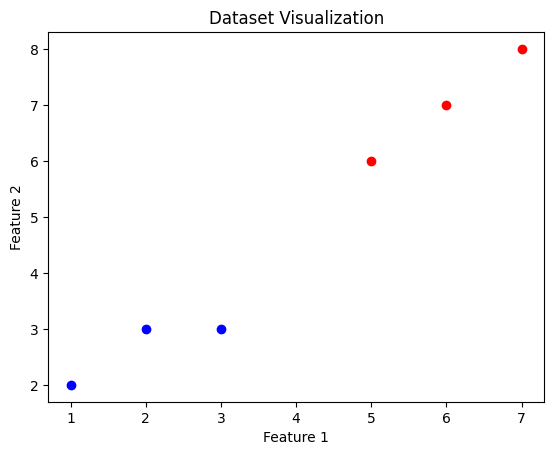

In [10]:
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='blue')
    else:
        plt.scatter(X[i][0], X[i][1], color='red')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Visualization")
plt.show()

In [11]:
w = np.zeros(X.shape[1])
b = 0

learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    
    # Step 1: Prediction
    y_pred = predict_proba(X, w, b)
    
    # Step 2: Loss
    loss = compute_loss(y, y_pred)
    
    # Step 3: Error
    error = y_pred - y
    
    # Step 4: Gradients
    dw = (1/len(y)) * np.dot(X.T, error)
    db = (1/len(y)) * np.sum(error)
    
    # Step 5: Update
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471805599452
Epoch 100, Loss: 0.5650632964333021
Epoch 200, Loss: 0.5308984181452514
Epoch 300, Loss: 0.5002136725986941
Epoch 400, Loss: 0.4726176364467379
Epoch 500, Loss: 0.4477496684147799
Epoch 600, Loss: 0.42528416220443055
Epoch 700, Loss: 0.4049314569708374
Epoch 800, Loss: 0.3864365703486341
Epoch 900, Loss: 0.3695766682032805


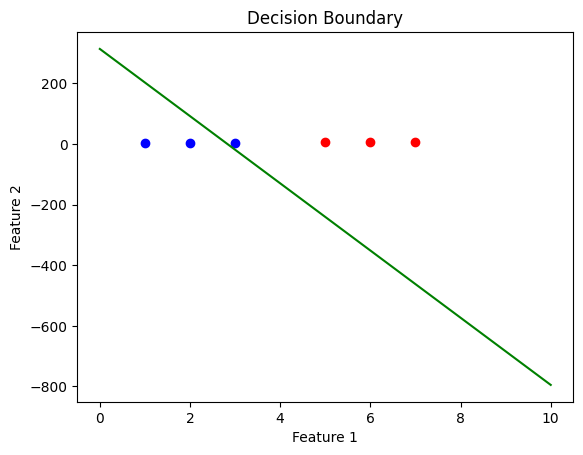

In [12]:
# Plot data again
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='blue')
    else:
        plt.scatter(X[i][0], X[i][1], color='red')

# Decision boundary
x1 = np.linspace(0, 10, 100)

# w1*x1 + w2*x2 + b = 0 → solve for x2
x2 = -(w[0]*x1 + b) / w[1]

plt.plot(x1, x2, color='green')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()

In [13]:
df = pd.read_csv("../Datasets/employee_turnover.csv")

In [14]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1.350000e+03,1350.000000,1350.000000
mean,0.506386,0.487061,0.484761,0.499442,0.494884,0.509909,0.504329,0.500164,0.516149,0.506091,0.493360,0.486843,0.485767,3.291479e-01,0.240653,0.497778
std,0.291505,0.283808,0.282758,0.293013,0.289248,0.290110,0.295693,0.294835,0.295072,0.284901,0.292929,0.288342,0.285077,2.986314e-01,0.222281,0.500180
min,0.001738,0.000546,0.001545,0.000166,0.001319,0.005015,0.000424,0.000231,0.000150,0.000903,0.000491,0.001293,0.001595,2.410000e-07,0.000247,0.000000
25%,0.263051,0.238538,0.249651,0.246399,0.244162,0.263235,0.249894,0.239224,0.247978,0.269517,0.247274,0.233357,0.244944,6.114448e-02,0.058694,0.000000
50%,0.525340,0.468457,0.485414,0.495572,0.501617,0.532388,0.509448,0.499964,0.531408,0.504640,0.498490,0.475214,0.468982,2.484923e-01,0.165438,0.000000
75%,0.750987,0.724088,0.721622,0.753108,0.743938,0.761090,0.755113,0.767168,0.775888,0.761640,0.740231,0.747609,0.725870,5.479425e-01,0.367042,1.000000
max,0.998692,0.999957,0.999722,0.999931,0.997813,0.999143,0.999794,0.998365,0.999962,0.999964,0.998211,0.998330,0.999386,9.964245e-01,0.930338,1.000000


In [16]:

# assuming df is your dataset
X = df.drop("Employee_Turnover", axis=1).values
y = df["Employee_Turnover"].values

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
w = np.zeros(X_train.shape[1])
b = 0
learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    
    y_pred = predict_proba(X_train, w, b)
    
    loss = compute_loss(y_train, y_pred)
    
    error = y_pred - y_train
    
    dw = (1/len(y_train)) * np.dot(X_train.T, error)
    db = (1/len(y_train)) * np.sum(error)
    
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471805599453
Epoch 100, Loss: 0.5836818855062508
Epoch 200, Loss: 0.5149730628418717
Epoch 300, Loss: 0.46926684209487024
Epoch 400, Loss: 0.4371037824996813
Epoch 500, Loss: 0.41339711596405665
Epoch 600, Loss: 0.39526705939759016
Epoch 700, Loss: 0.3809886178871605
Epoch 800, Loss: 0.36947427903360613
Epoch 900, Loss: 0.36000755351912606


In [20]:
y_pred_test = predict(X_test, w, b)

In [21]:
accuracy = np.mean(y_pred_test == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8592592592592593


In [22]:
tp = np.sum((y_test == 1) & (y_pred_test == 1))
tn = np.sum((y_test == 0) & (y_pred_test == 0))
fp = np.sum((y_test == 0) & (y_pred_test == 1))
fn = np.sum((y_test == 1) & (y_pred_test == 0))

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 103
TN: 129
FP: 16
FN: 22


In [23]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.865546218487395
Recall: 0.824


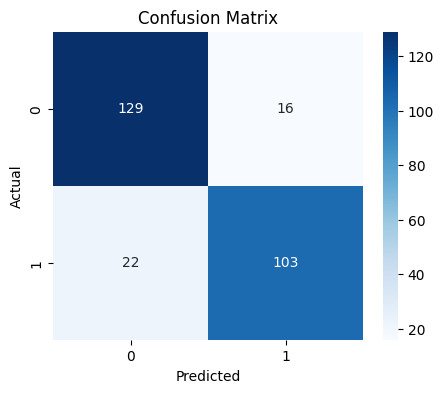

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[tn, fp],
               [fn, tp]])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

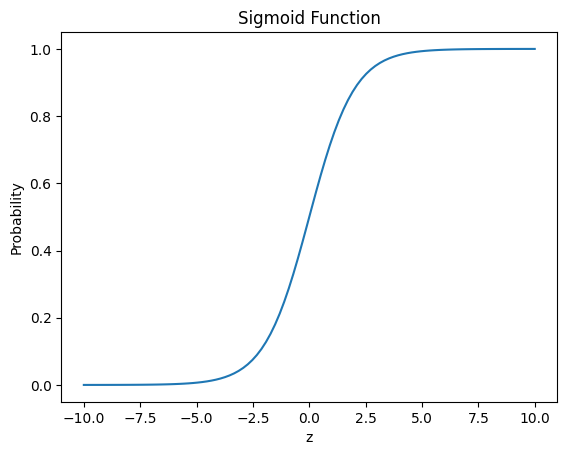

In [25]:
z = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-z))

plt.plot(z, sig)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()

In [ ]:
# X_vis = df[["Age", "Monthly_Income"]].values
# y_vis = df["Employee_Turnover"].values

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler_vis = StandardScaler()
# X_vis = scaler_vis.fit_transform(X_vis)

In [ ]:
# w = np.zeros(2)
# b = 0

# for i in range(1000):
#     y_pred = sigmoid(np.dot(X_vis, w) + b)
#     error = y_pred - y_vis
    
#     dw = (1/len(y_vis)) * np.dot(X_vis.T, error)
#     db = (1/len(y_vis)) * np.sum(error)
    
#     w -= 0.01 * dw
#     b -= 0.01 * db

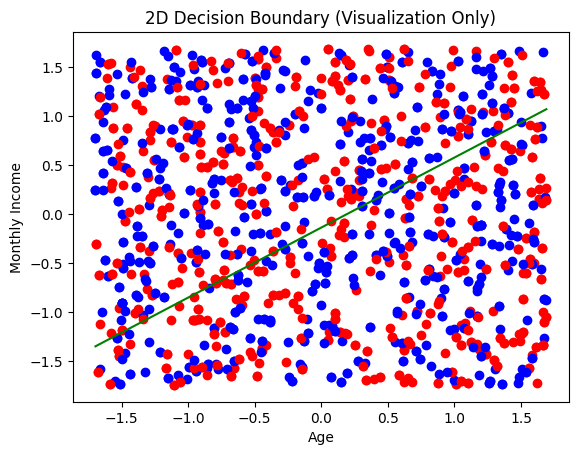

In [ ]:
# import matplotlib.pyplot as plt

# # scatter
# for i in range(len(y_vis)):
#     if y_vis[i] == 0:
#         plt.scatter(X_vis[i][0], X_vis[i][1], color='blue')
#     else:
#         plt.scatter(X_vis[i][0], X_vis[i][1], color='red')

# # decision boundary
# x1 = np.linspace(X_vis[:,0].min(), X_vis[:,0].max(), 100)
# x2 = -(w[0]*x1 + b) / w[1]

# plt.plot(x1, x2, color='green')

# plt.xlabel("Age")
# plt.ylabel("Monthly Income")
# plt.title("2D Decision Boundary (Visualization Only)")
# plt.show()

In [31]:
def predict_with_threshold(X, w, b, threshold):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

In [35]:
print(predict_with_threshold(X_test, w, b, 0.3))
print(predict_with_threshold(X_test, w, b, 0.7))

[1 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 0
 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0
 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1
 0 1 0 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0
 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 1 0
 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 1
 1 0 1 1 0 0 1 0 0 1 0]
[0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0
 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0
 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 1 0
 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0
 

In [36]:
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred = predict_with_threshold(X_test, w, b, t)
    
    tp = np.sum((y_test == 1) & (y_pred == 1))
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    
    print(f"\nThreshold: {t}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)


Threshold: 0.3
Precision: 0.7159763313609467
Recall: 0.968
TP: 121 FP: 48 FN: 4 TN: 97

Threshold: 0.5
Precision: 0.865546218487395
Recall: 0.824
TP: 103 FP: 16 FN: 22 TN: 129

Threshold: 0.7
Precision: 0.9736842105263158
Recall: 0.592
TP: 74 FP: 2 FN: 51 TN: 143


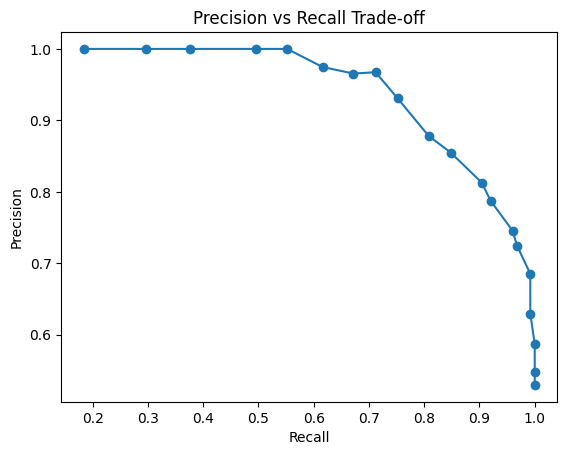

In [37]:
thresholds = np.linspace(0.1, 0.9, 20)

precisions = []
recalls = []

for t in thresholds:
    y_pred = predict_with_threshold(X_test, w, b, t)
    
    tp = np.sum((y_test == 1) & (y_pred == 1))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    
    precisions.append(precision)
    recalls.append(recall)

import matplotlib.pyplot as plt

plt.plot(recalls, precisions, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Trade-off")
plt.show()